# loss_02 — L1 Reserving (Expected Loss & ECL)

**Owner:** Shuxin · **Layer:** L1 (Reserving / CECL / EL)

**Question we answer:** *How much loan-loss provision should we book against the 2018Q4 portfolio today?*

This notebook delivers the five L1 outputs from our framework one-pager:

| # | Deliverable | Section |
|---|---|---|
| 1 | **12m EL decomposition** by grade × term × purpose | §2.5 |
| 2 | **Lifetime ECL** using term-specific Cox PD (no constant-hazard extrapolation) | §2.6 |
| 3 | **2016-vintage backtest** — 4 cohorts fully observed at 12m & 24m | §2.7 |
| 4 | **Model-risk sensitivity panel** — Logit vs RF vs Cox band on ECL | §2.8 |
| 5 | **Final reserve recommendation** = base ECL + backtest overlay + model-risk overlay | §2.9 |


## 2.1 Imports & Paths

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# TODO: paths to your local files
RAW_DIR        = Path("/Users/dongshuxin/Desktop/Projects/data")
ACCEPTED_FILE  = RAW_DIR / "accepted_2007_to_2018Q4.csv.gz"

PD_FILE        = Path("data/pd_predictions.csv")
LGD_DECISION   = Path("data/processed/lgd_decision.json")

OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Inputs:")
print("  PD :", PD_FILE,       "exists =", PD_FILE.exists())
print("  LGD:", LGD_DECISION,  "exists =", LGD_DECISION.exists())
print("  RAW:", ACCEPTED_FILE, "exists =", ACCEPTED_FILE.exists())

Inputs:
  PD : data/pd_predictions.csv exists = True
  LGD: data/processed/lgd_decision.json exists = True
  RAW: /Users/dongshuxin/Desktop/Projects/data/accepted_2007_to_2018Q4.csv.gz exists = True


## 2.2 Load PD predictions and the LGD constant from `loss_01`

We treat `LGD_CONST` as a single number sourced from `loss_01`'s decision file (mature-window calibration on outstanding convention).

In [2]:
with open(LGD_DECISION) as f:
    lgd_dec = json.load(f)

LGD_CONST = float(lgd_dec["lgd_const_outstanding_mature"])
print(f"LGD_CONST = {LGD_CONST:.4f}  (source: {LGD_DECISION.name})")
print(f"  calibration window: {lgd_dec['calibration_window']}")
print(f"  n defaults used   : {lgd_dec['n_defaults_mature']:,}")

pd_df = pd.read_csv(PD_FILE)
print(f"\npd_predictions.csv : {len(pd_df):,} rows, {pd_df.shape[1]} cols")
print("PD columns available:")
print([c for c in pd_df.columns if c.startswith("pd_")])

LGD_CONST = 0.9013  (source: lgd_decision.json)
  calibration window: [2010, 2016]
  n defaults used   : 219,670

pd_predictions.csv : 2,260,668 rows, 32 cols
PD columns available:
['pd_6m_logit', 'pd_12m_logit', 'pd_18m_logit', 'pd_24m_logit', 'pd_6m_rf', 'pd_12m_rf', 'pd_18m_rf', 'pd_24m_rf', 'pd_6m_cox_raw', 'pd_18m_cox_raw', 'pd_24m_cox_raw', 'pd_24m_cox', 'pd_36m_cox_raw', 'pd_36m_cox', 'pd_60m_cox_raw', 'pd_60m_cox', 'pd_24m_chosen']


## 2.3 Join in fields we need from the raw CSV



In [5]:
RAW_COLS = [
    "id",
    "purpose", "int_rate", "addr_state", "home_ownership",
    "funded_amnt",
    "total_rec_prncp", "recoveries", "collection_recovery_fee",
    "out_prncp", "last_pymnt_d",
]
raw = pd.read_csv(ACCEPTED_FILE, usecols=RAW_COLS, low_memory=False)
print(f"raw subset: {len(raw):,} rows")

# Force id to string on both sides
pd_df["id"] = pd_df["id"].astype(str)
raw["id"]   = raw["id"].astype(str)

# Drop any columns from raw that pd_df already has (avoid _x/_y suffix collision)
overlap = (set(raw.columns) & set(pd_df.columns)) - {"id"}
if overlap:
    print(f"Note: dropping overlapping cols from raw (kept pd_df version): {overlap}")
    raw = raw.drop(columns=list(overlap))

df = pd_df.merge(raw, on="id", how="left", validate="m:1")
print(f"after join: {len(df):,} rows, {df.shape[1]} cols")

# Sanity check: do we actually have what we need downstream?
needed = ["purpose", "int_rate", "funded_amnt",
          "total_rec_prncp", "recoveries", "collection_recovery_fee",
          "out_prncp", "last_pymnt_d"]
missing = [c for c in needed if c not in df.columns]
print(f"missing required cols: {missing if missing else 'none ✓'}")
print(f"missing purpose values: {df['purpose'].isna().sum():,}")
df.head(3)

raw subset: 2,260,701 rows
Note: dropping overlapping cols from raw (kept pd_df version): {'int_rate', 'purpose', 'addr_state', 'home_ownership'}
after join: 2,260,668 rows, 38 cols
missing required cols: none ✓
missing purpose values: 0


,id,grade,issue_d,loan_status,loan_amnt,int_rate,annual_inc,dti,fico_avg,term_num,...,pd_36m_cox,pd_60m_cox_raw,pd_60m_cox,pd_24m_chosen,funded_amnt,out_prncp,total_rec_prncp,recoveries,collection_recovery_fee,last_pymnt_d
0,68407277,C,2015-12-01,Fully Paid,3600.0,13.99,55000.0,5.91,677.0,36.0,...,0.090164,NaN,NaN,0.068016,3600.0,0.0,3600.0,0.0,0.0,Jan-2019
1,68355089,C,2015-12-01,Fully Paid,24700.0,11.99,65000.0,16.06,717.0,36.0,...,0.371731,NaN,NaN,0.228257,24700.0,0.0,24700.0,0.0,0.0,Jun-2016
2,68341763,B,2015-12-01,Fully Paid,20000.0,10.78,63000.0,10.78,697.0,60.0,...,0.085685,0.216771,0.170025,0.063312,20000.0,0.0,20000.0,0.0,0.0,Jun-2017


## 2.4 Define EAD and a few helpers

**EAD convention (consistent with `loss_01`):** outstanding-balance view.


In [15]:
# Issue date / vintage  (auto-detect format — works for both "Jan-2016" and "2016-01-01")
df["issue_dt"]      = pd.to_datetime(df["issue_d"], errors="coerce")
df["vintage_year"]  = df["issue_dt"].dt.year
df["vintage_q"]     = df["issue_dt"].dt.to_period("Q").astype(str)

# Last-payment date (proxy for default time on charged-off loans)
df["last_pymnt_dt"] = pd.to_datetime(df["last_pymnt_d"], errors="coerce")
df["months_to_event"] = ((df["last_pymnt_dt"] - df["issue_dt"]).dt.days / 30.44).round(1)

# Active-loan flag (for forward-looking ECL on 2018Q4 portfolio)
ACTIVE_STATUSES = ["Current", "In Grace Period", "Late (16-30 days)", "Late (31-120 days)"]
df["is_active"] = df["loan_status"].isin(ACTIVE_STATUSES)

# Forward EAD = current outstanding principal (out_prncp), filled with funded_amnt for safety
df["ead_forward"]   = df["out_prncp"].fillna(df["funded_amnt"]).clip(lower=0)
# Backtest EAD = funded amount at origination
df["ead_backtest"]  = df["funded_amnt"].fillna(df["loan_amnt"])

print(f"Active loans at 2018Q4 snapshot: {df['is_active'].sum():,}  ({df['is_active'].mean():.1%})")
print(f"  total forward EAD on active book: ${df.loc[df['is_active'],'ead_forward'].sum()/1e9:.2f}B")
print(f"\nVintage years available: {sorted(df['vintage_year'].dropna().unique().astype(int))}")

Active loans at 2018Q4 snapshot: 912,569  (40.4%)
  total forward EAD on active book: $9.51B

Vintage years available: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


## 2.5  Deliverable 1 — 12-month EL decomposition by grade × term × purpose

For each currently-active loan, compute:

$$\text{EL}_{12m} \;=\; \text{pd\_12m\_logit} \times \text{LGD\_CONST} \times \text{ead\_forward}$$

Find *where* the expected loss concentrates from three management-relevant dimensions.

In [16]:
active = df[df["is_active"]].copy()

active["el_12m"] = active["pd_12m_logit"] * LGD_CONST * active["ead_forward"]

# 1) By grade
by_grade = (active.groupby("grade")
                  .agg(n=("id","count"),
                       ead=("ead_forward","sum"),
                       el_12m=("el_12m","sum"))
                  .assign(el_rate=lambda x: x["el_12m"]/x["ead"]))
print("=== EL by grade ===")
print(by_grade.round({"n":0, "ead":0, "el_12m":0, "el_rate":4}))

# 2) By term
by_term = (active.groupby("term_num")
                 .agg(n=("id","count"),
                      ead=("ead_forward","sum"),
                      el_12m=("el_12m","sum"))
                 .assign(el_rate=lambda x: x["el_12m"]/x["ead"]))
print("\n=== EL by term ===")
print(by_term.round({"n":0, "ead":0, "el_12m":0, "el_rate":4}))

# 3) By purpose (top 8 by EAD)
by_purpose = (active.groupby("purpose")
                    .agg(n=("id","count"),
                         ead=("ead_forward","sum"),
                         el_12m=("el_12m","sum"))
                    .assign(el_rate=lambda x: x["el_12m"]/x["ead"])
                    .sort_values("ead", ascending=False)
                    .head(8))
print("\n=== EL by purpose (top 8) ===")
print(by_purpose.round({"n":0, "ead":0, "el_12m":0, "el_rate":4}))

=== EL by grade ===
            n           ead       el_12m  el_rate
grade                                            
A      197834  2.002637e+09   45412554.0   0.0227
B      270455  2.675935e+09   89885077.0   0.0336
C      267730  2.847221e+09  143946816.0   0.0506
D      122767  1.368536e+09  111581326.0   0.0815
E       41447  4.553417e+08   58534616.0   0.1286
F        9494  1.201698e+08   22258637.0   0.1852
G        2842  4.016190e+07    9227270.0   0.2298

=== EL by term ===
               n           ead       el_12m  el_rate
term_num                                            
36.0      586548  4.637651e+09  227901355.0   0.0491
60.0      326021  4.872350e+09  252944942.0   0.0519

=== EL by purpose (top 8) ===
                         n           ead       el_12m  el_rate
purpose                                                       
debt_consolidation  496435  5.555920e+09  302224354.0   0.0544
credit_card         221346  2.307041e+09   87058547.0   0.0377
home_improvemen

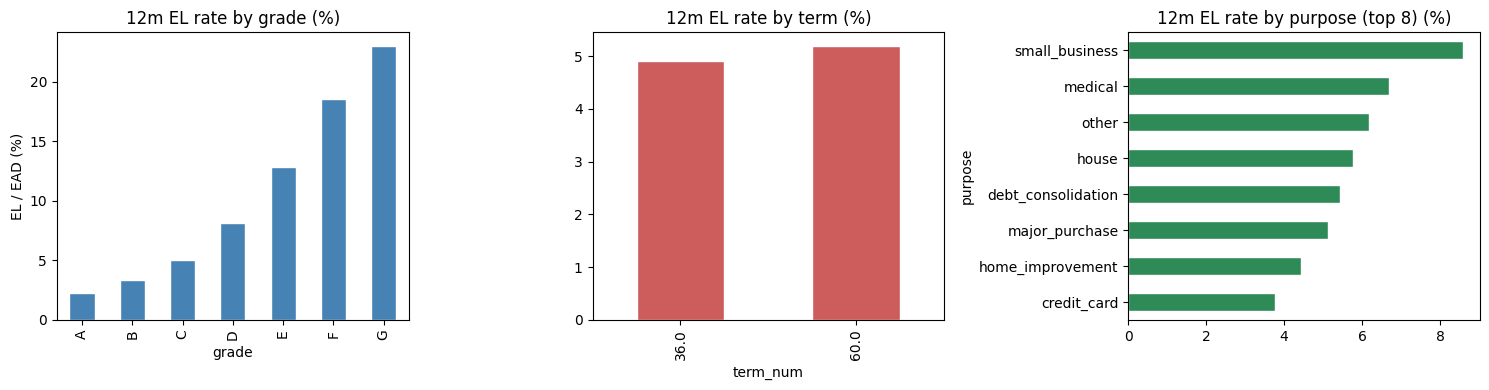

In [17]:
# Visualize the decomposition
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

(by_grade["el_rate"]*100).plot(kind="bar", ax=ax[0], color="steelblue", edgecolor="white")
ax[0].set_title("12m EL rate by grade (%)")
ax[0].set_ylabel("EL / EAD (%)")

(by_term["el_rate"]*100).plot(kind="bar", ax=ax[1], color="indianred", edgecolor="white")
ax[1].set_title("12m EL rate by term (%)")

(by_purpose["el_rate"]*100).sort_values().plot(kind="barh", ax=ax[2], color="seagreen", edgecolor="white")
ax[2].set_title("12m EL rate by purpose (top 8) (%)")

plt.tight_layout(); plt.show()

=== Risk concentration by grade ===
            EAD_$M  EAD_%       EL_$M   EL_%  EL/EAD amp
grade                                                   
A      2002.600000   21.1   45.400000    9.4        0.45
B      2675.900000   28.1   89.900000   18.7        0.67
C      2847.200000   29.9  143.900000   29.9        1.00
D      1368.500000   14.4  111.600000   23.2        1.61
E       455.300000    4.8   58.500000   12.2        2.54
F       120.200000    1.3   22.300000    4.6        3.54
G        40.200000    0.4    9.200000    1.9        4.75
Total  9510.001923  100.0  480.846297  100.0        1.00

Key insight: grades ['D', 'E', 'F', 'G'] together hold 20.9% of EAD but generate 41.9% of 12m EL (2.00x amplification).


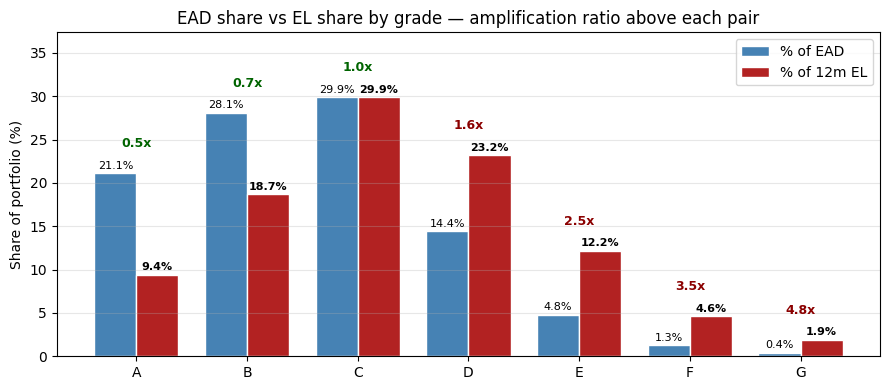

In [ ]:
# --- Concentration check: where is the loss really sitting? ---

total_ead = by_grade["ead"].sum()
total_el  = by_grade["el_12m"].sum()

concentration = pd.DataFrame({
    "EAD_$M":  by_grade["ead"]    / 1e6,
    "EAD_%":   by_grade["ead"]    / total_ead * 100,
    "EL_$M":   by_grade["el_12m"] / 1e6,
    "EL_%":    by_grade["el_12m"] / total_el  * 100,
}).round(1)

# Amplification = EL share / EAD share. >1 means this grade is "louder" on losses than on size.
concentration["EL/EAD amp"] = (concentration["EL_%"] / concentration["EAD_%"]).round(2)

# Total row
concentration.loc["Total"] = [
    total_ead/1e6, 100.0, total_el/1e6, 100.0, 1.00
]

print("=== Risk concentration by grade ===")
print(concentration)

# Where does the amplification flip from <1 (safe) to >1 (risk-heavy)?
flip_grades = concentration.loc[concentration["EL/EAD amp"] > 1].index.tolist()
flip_grades = [g for g in flip_grades if g != "Total"]
amp_ead  = concentration.loc[flip_grades, "EAD_%"].sum()
amp_el   = concentration.loc[flip_grades, "EL_%"].sum()
print(f"\nKey insight: grades {flip_grades} together hold {amp_ead:.1f}% of EAD "
      f"but generate {amp_el:.1f}% of 12m EL "
      f"({amp_el/amp_ead:.2f}x amplification).")

# --- Visual: side-by-side bars per grade ---
fig, ax = plt.subplots(figsize=(9, 4))
grades = [g for g in concentration.index if g != "Total"]
x = np.arange(len(grades))
width = 0.38

ead_pct = concentration.loc[grades, "EAD_%"].values
el_pct  = concentration.loc[grades, "EL_%"].values

ax.bar(x - width/2, ead_pct, width, label="% of EAD",   color="steelblue", edgecolor="white")
ax.bar(x + width/2, el_pct,  width, label="% of 12m EL", color="firebrick",  edgecolor="white")

# Value labels
for i, (e, l) in enumerate(zip(ead_pct, el_pct)):
    ax.text(i - width/2, e + 0.5, f"{e:.1f}%", ha="center", fontsize=8)
    ax.text(i + width/2, l + 0.5, f"{l:.1f}%", ha="center", fontsize=8, fontweight="bold")

# Amplification annotation above each grade
for i, g in enumerate(grades):
    amp = concentration.loc[g, "EL/EAD amp"]
    color = "darkred" if amp > 1 else "darkgreen"
    ax.text(i, max(ead_pct[i], el_pct[i]) + 3.0, f"{amp:.1f}x",
            ha="center", fontsize=9, color=color, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(grades)
ax.set_ylabel("Share of portfolio (%)")
ax.set_title("EAD share vs EL share by grade — amplification ratio above each pair")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(max(ead_pct), max(el_pct)) * 1.25)

plt.tight_layout(); plt.show()

## 2.6  Deliverable 2 — Lifetime ECL using **term-specific** Cox PD
We use the model-team's term-matched Cox horizons:

- 36-month loans → `pd_36m_cox`
- 60-month loans → `pd_60m_cox`

This is the closest thing to a true CECL "lifetime" PD given the data.

In [18]:
def lifetime_pd(row):
    if row["term_num"] == 36:
        return row["pd_36m_cox"]
    elif row["term_num"] == 60:
        return row["pd_60m_cox"]
    return np.nan

active["pd_lifetime"] = active.apply(lifetime_pd, axis=1)
active["ecl_lifetime"] = active["pd_lifetime"] * LGD_CONST * active["ead_forward"]

ecl_summary = pd.DataFrame({
    "metric":  ["12m EL ($)", "Lifetime ECL ($)", "Ratio (lifetime / 12m)"],
    "value":   [active["el_12m"].sum(),
                active["ecl_lifetime"].sum(),
                active["ecl_lifetime"].sum() / active["el_12m"].sum()],
})
ecl_summary["value"] = ecl_summary["value"].apply(lambda v: f"${v/1e6:.1f}M" if v > 1000 else f"{v:.2f}x")
print(ecl_summary.to_string(index=False))

# Lifetime ECL by grade × term
ecl_grid = (active.groupby(["grade","term_num"])["ecl_lifetime"]
                  .sum().unstack().fillna(0).round(0))
print("\n=== Lifetime ECL ($) by grade × term ===")
print(ecl_grid.applymap(lambda v: f"${v/1e6:.1f}M"))

                metric    value
            12m EL ($)  $480.8M
      Lifetime ECL ($) $2055.5M
Ratio (lifetime / 12m)    4.27x

=== Lifetime ECL ($) by grade × term ===
term_num     36.0     60.0
grade                     
A         $147.2M   $55.8M
B         $183.8M  $302.0M
C         $168.9M  $555.5M
D          $81.5M  $336.9M
E          $20.9M  $136.6M
F           $1.5M   $47.9M
G           $0.8M   $16.1M


## 2.7  Deliverable 3 — 2016-vintage backtest (4 cohorts, 12m & 24m)

We chose 2016 because:
- All 4 quarters are **fully observed** at both 12m and 24m by the 2018Q4 snapshot
- 2016 is in the model's **test set** (model didn't see these loans during training)
- 2016 vintage recovery is mature enough for realized losses to be meaningful


In [19]:
DEFAULT_STATUSES = ["Charged Off", "Default"]
df["is_default"] = df["loan_status"].isin(DEFAULT_STATUSES)

# Realized loss per defaulted loan
df["net_recov"]      = df["recoveries"].fillna(0) - df["collection_recovery_fee"].fillna(0)
df["prncp_paid"]     = df["total_rec_prncp"].fillna(0)
df["realized_loss"]  = (df["ead_backtest"] - df["prncp_paid"] - df["net_recov"]).clip(lower=0)

# --- Diagnostic: what vintages are actually in pd_predictions? ---
print("Vintage year distribution in df:")
print(df["vintage_year"].value_counts(dropna=False).sort_index())
print(f"\nNaN vintage_year count: {df['vintage_year'].isna().sum():,}")
print(f"Sample issue_d values: {df['issue_d'].dropna().sample(min(5,len(df))).tolist()}")
print(f"Sample issue_dt values: {df['issue_dt'].dropna().sample(min(5,len(df))).tolist()}")

# 2016 cohort
v2016 = df[df["vintage_year"] == 2016].copy()
print(f"\n2016 vintage: {len(v2016):,} loans across {v2016['vintage_q'].nunique()} quarters")

if len(v2016) == 0:
    print("\n⚠️  WARNING: no 2016 vintage loans found. Check: ")
    print("   - Does pd_predictions.csv include 2016? (teammate's test set may start later)")
    print("   - Did issue_d parse correctly? (try a different date format)")
    backtest = pd.DataFrame(columns=["cohort","horizon","n","predicted_EL","realized_loss","coverage_ratio"])
else:
    def backtest_cohort(cohort_df, horizon_months):
        pd_col = f"pd_{horizon_months}m_logit"
        pred = (cohort_df[pd_col] * LGD_CONST * cohort_df["ead_backtest"]).sum()
        defaulted_within = (cohort_df["is_default"]
                            & (cohort_df["months_to_event"] <= horizon_months))
        real = cohort_df.loc[defaulted_within, "realized_loss"].sum()
        return pred, real

    rows = []
    for q in sorted(v2016["vintage_q"].unique()):
        cohort = v2016[v2016["vintage_q"] == q]
        for h in [12, 24]:
            pred, real = backtest_cohort(cohort, h)
            rows.append({
                "cohort": q, "horizon": f"{h}m",
                "n": len(cohort),
                "predicted_EL": pred,
                "realized_loss": real,
                "coverage_ratio": pred / real if real > 0 else np.nan,
            })
    backtest = pd.DataFrame(rows)

# Round only when the columns actually exist
if not backtest.empty:
    backtest["predicted_EL"]   = backtest["predicted_EL"].round(0)
    backtest["realized_loss"]  = backtest["realized_loss"].round(0)
    backtest["coverage_ratio"] = backtest["coverage_ratio"].round(3)

print("\n=== 2016 vintage backtest ===")
print(backtest)

Vintage year distribution in df:
vintage_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134814
2014    235629
2015    421095
2016    434407
2017    443579
2018    495242
Name: count, dtype: int64

NaN vintage_year count: 0
Sample issue_d values: ['2016-02-01', '2011-12-01', '2017-12-01', '2017-05-01', '2017-06-01']
Sample issue_dt values: [Timestamp('2016-12-01 00:00:00'), Timestamp('2018-08-01 00:00:00'), Timestamp('2016-11-01 00:00:00'), Timestamp('2017-03-01 00:00:00'), Timestamp('2015-08-01 00:00:00')]

2016 vintage: 434,407 loans across 4 quarters

=== 2016 vintage backtest ===
   cohort horizon       n  predicted_EL  realized_loss  coverage_ratio
0  2016Q1     12m  133887   104758556.0    113336923.0           0.924
1  2016Q1     24m  133887   232352709.0    203886349.0           1.140
2  2016Q2     12m   97854    73658025.0     81014964.0           0.909
3  2016Q2     24m   97854   160954809.0    141043349.0           1.141

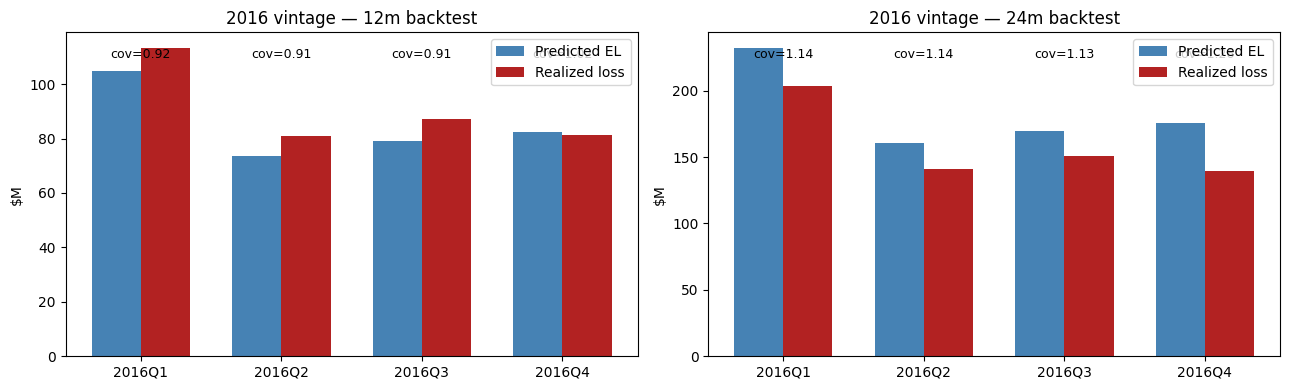


=== Pooled coverage across 4 cohorts ===
         predicted_EL  realized_loss  coverage_ratio
horizon                                             
12m       339981142.0    362840760.0           0.937
24m       738650481.0    635229989.0           1.163


In [20]:
# Visualize backtest
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

for i, h in enumerate(["12m", "24m"]):
    sub = backtest[backtest["horizon"] == h]
    x = np.arange(len(sub))
    width = 0.35
    ax[i].bar(x - width/2, sub["predicted_EL"]/1e6,  width, label="Predicted EL", color="steelblue")
    ax[i].bar(x + width/2, sub["realized_loss"]/1e6, width, label="Realized loss",  color="firebrick")
    ax[i].set_xticks(x); ax[i].set_xticklabels(sub["cohort"], rotation=0)
    ax[i].set_title(f"2016 vintage — {h} backtest")
    ax[i].set_ylabel("$M")
    ax[i].legend()
    # annotate coverage ratio
    for j, cr in enumerate(sub["coverage_ratio"]):
        ax[i].text(j, ax[i].get_ylim()[1]*0.92, f"cov={cr:.2f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

# Pooled coverage (across all 4 quarters)
pooled = backtest.groupby("horizon")[["predicted_EL","realized_loss"]].sum()
pooled["coverage_ratio"] = (pooled["predicted_EL"] / pooled["realized_loss"]).round(3)
print("\n=== Pooled coverage across 4 cohorts ===")
print(pooled)

## 2.8  Deliverable 4 — Model-risk sensitivity panel

Same EL calculation, three different models:
- **Logit** — interpretable baseline
- **Random Forest** — non-linear interactions
- **Cox** — survival-aware (only 24m here, since `pd_12m_cox` may not be in the file)
- **Median ensemble** — robust central estimate

The **range** between min and max is our model-risk overlay budget.

horizon  model  EL_$M
    12m  Logit  480.8
    12m     RF  455.1
    24m  Logit 1056.7
    24m     RF 1037.0
    24m    Cox 1127.6
    24m Median 1066.5

=== Model-risk band ===
            min  median     max  range_$M  range_pct
horizon                                             
12m       455.1   468.0   480.8      25.8        5.5
24m      1037.0  1061.6  1127.6      90.5        8.5


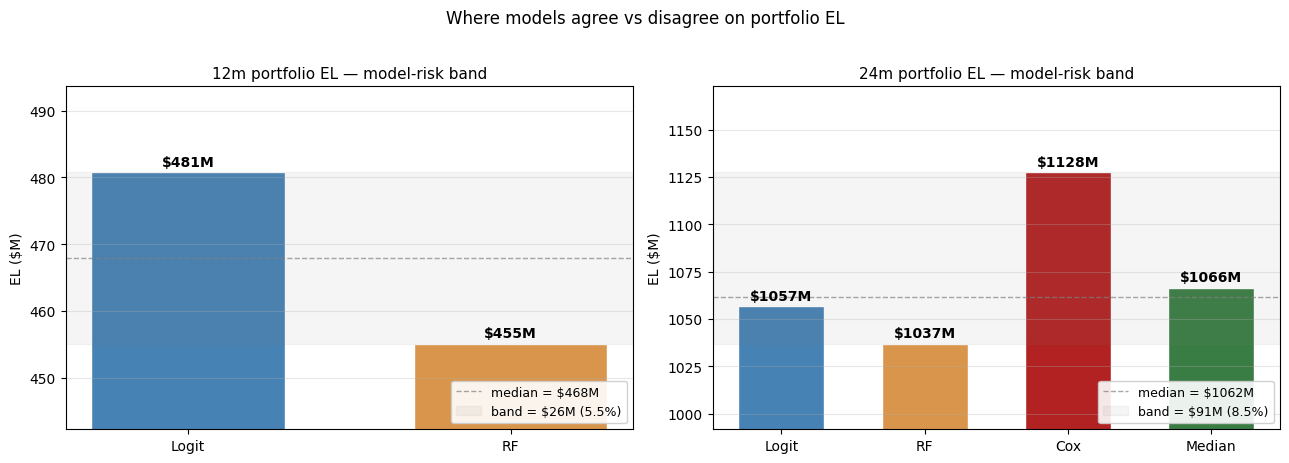

In [22]:
def el_under_model(active_df, pd_col, horizon_label):
    return (active_df[pd_col] * LGD_CONST * active_df["ead_forward"]).sum()

panels = []
# 12m: logit, rf (no cox at 12m)
panels.append({"horizon":"12m", "model":"Logit",  "EL": el_under_model(active, "pd_12m_logit", "12m")})
panels.append({"horizon":"12m", "model":"RF",     "EL": el_under_model(active, "pd_12m_rf",    "12m")})

# 24m: logit, rf, cox, median (chosen)
panels.append({"horizon":"24m", "model":"Logit",  "EL": el_under_model(active, "pd_24m_logit",  "24m")})
panels.append({"horizon":"24m", "model":"RF",     "EL": el_under_model(active, "pd_24m_rf",     "24m")})
panels.append({"horizon":"24m", "model":"Cox",    "EL": el_under_model(active, "pd_24m_cox",    "24m")})
panels.append({"horizon":"24m", "model":"Median", "EL": el_under_model(active, "pd_24m_chosen", "24m")})

risk = pd.DataFrame(panels)
risk["EL_$M"] = (risk["EL"] / 1e6).round(1)
print(risk[["horizon","model","EL_$M"]].to_string(index=False))

# Compute model-risk band (max - min within each horizon)
band = risk.groupby("horizon")["EL"].agg(["min","median","max"]) / 1e6
band["range_$M"]  = (band["max"] - band["min"]).round(1)
band["range_pct"] = ((band["max"] - band["min"]) / band["median"] * 100).round(1)
print("\n=== Model-risk band ===")
print(band.round(1))

# Plot
# ---- Replace ONLY the plotting block at the bottom of §2.8 ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
colors = {"Logit":"steelblue", "RF":"#d9954b", "Cox":"firebrick", "Median":"#3a7d44"}

for ax, h in zip(axes, ["12m", "24m"]):
    sub = risk[risk["horizon"] == h].copy()
    bars = ax.bar(sub["model"], sub["EL_$M"],
                  color=[colors[m] for m in sub["model"]],
                  edgecolor="white", width=0.6)

    # Median line + shaded band
    band_min, band_max = sub["EL_$M"].min(), sub["EL_$M"].max()
    band_med = sub["EL_$M"].median()
    ax.axhline(band_med, color="gray", linestyle="--", linewidth=1, alpha=0.7,
               label=f"median = ${band_med:.0f}M")
    ax.axhspan(band_min, band_max, color="gray", alpha=0.08,
               label=f"band = ${band_max-band_min:.0f}M ({(band_max-band_min)/band_med*100:.1f}%)")

    # Value labels on bars
    for bar, val in zip(bars, sub["EL_$M"]):
        ax.text(bar.get_x() + bar.get_width()/2, val + (band_max-band_min)*0.02,
                f"${val:.0f}M", ha="center", va="bottom", fontsize=10, fontweight="bold")

    # Cosmetic: zoom y-axis around the band so differences are visible
    span = band_max - band_min
    ax.set_ylim(band_min - span*0.5, band_max + span*0.5)
    ax.set_title(f"{h} portfolio EL — model-risk band", fontsize=11)
    ax.set_ylabel("EL ($M)")
    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Where models agree vs disagree on portfolio EL", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## 2.9  Deliverable 5 — Final reserve recommendation

`Final reserve = Base + max(Backtest overlay, 0) + Model-risk overlay`



In [23]:
# 1) Base = lifetime ECL via median ensemble
#    Approximate lifetime via term-specific Cox (already in pd_lifetime)
base_ecl = active["ecl_lifetime"].sum()

# 2) Backtest overlay — use 12m pooled coverage as the calibration signal
cov_12m = float(pooled.loc["12m", "coverage_ratio"])
backtest_overlay = max(0.0, base_ecl * (1/cov_12m - 1))   # only adds if model under-predicts

# 3) Model-risk overlay — half of 24m band (proxy for lifetime uncertainty)
band_24m = float(band.loc["24m", "range_$M"]) * 1e6
mr_overlay = 0.5 * band_24m

final_reserve = base_ecl + backtest_overlay + mr_overlay

reserve_table = pd.DataFrame([
    {"component": "Base lifetime ECL (median Cox)",  "amount_$M": base_ecl/1e6},
    {"component": "Backtest overlay (1/cov - 1)",    "amount_$M": backtest_overlay/1e6},
    {"component": "Model-risk overlay (½ band)",     "amount_$M": mr_overlay/1e6},
    {"component": "**Final reserve recommendation**","amount_$M": final_reserve/1e6},
]).round(2)
print(reserve_table.to_string(index=False))

# Reserve as % of active EAD
active_ead = active["ead_forward"].sum()
print(f"\nFinal reserve = ${final_reserve/1e6:.1f}M  ({final_reserve/active_ead*100:.2f}% of active EAD ${active_ead/1e9:.2f}B)")

                       component  amount_$M
  Base lifetime ECL (median Cox)    2055.52
    Backtest overlay (1/cov - 1)     138.20
     Model-risk overlay (½ band)      45.25
**Final reserve recommendation**    2238.97

Final reserve = $2239.0M  (23.54% of active EAD $9.51B)


## 2.10 Save outputs for downstream layers

`l1_reserving.json` is the contract object L2 (pricing) and L4 (stress) consume.

In [24]:
l1_output = {
    "lgd_const":                      LGD_CONST,
    "active_loans_n":                 int(active["is_active"].sum() if "is_active" in active else len(active)),
    "active_ead_$":                   float(active_ead),
    "el_12m_$":                       float(active["el_12m"].sum()),
    "ecl_lifetime_$":                 float(active["ecl_lifetime"].sum()),
    "backtest_pooled_coverage_12m":   cov_12m,
    "backtest_pooled_coverage_24m":   float(pooled.loc["24m", "coverage_ratio"]),
    "model_risk_band_24m_$M":         float(band.loc["24m", "range_$M"]),
    "final_reserve_$":                float(final_reserve),
    "final_reserve_pct_of_ead":       float(final_reserve / active_ead),
}
with open(OUT_DIR / "l1_reserving.json", "w") as f:
    json.dump(l1_output, f, indent=2)

# EL breakdown for L2/L3 to consume
breakdown = (active.groupby(["grade","term_num","purpose"])
                   .agg(n=("id","count"),
                        ead=("ead_forward","sum"),
                        el_12m=("el_12m","sum"),
                        ecl_lifetime=("ecl_lifetime","sum"))
                   .reset_index())
breakdown.to_csv(OUT_DIR / "l1_el_breakdown.csv", index=False)

print("Saved:")
print("  ", (OUT_DIR / "l1_reserving.json").resolve())
print("  ", (OUT_DIR / "l1_el_breakdown.csv").resolve())
print("\n--- L1 SUMMARY ---")
for k, v in l1_output.items():
    if isinstance(v, float) and v > 1e6:
        print(f"  {k:35s} ${v/1e6:.2f}M")
    elif isinstance(v, float):
        print(f"  {k:35s} {v:.4f}")
    else:
        print(f"  {k:35s} {v}")

Saved:
   /Users/dongshuxin/Desktop/IDS 583 Credit Risk Management Project/data/processed/l1_reserving.json
   /Users/dongshuxin/Desktop/IDS 583 Credit Risk Management Project/data/processed/l1_el_breakdown.csv

--- L1 SUMMARY ---
  lgd_const                           0.9013
  active_loans_n                      912569
  active_ead_$                        $9510.00M
  el_12m_$                            $480.85M
  ecl_lifetime_$                      $2055.52M
  backtest_pooled_coverage_12m        0.9370
  backtest_pooled_coverage_24m        1.1630
  model_risk_band_24m_$M              90.5000
  final_reserve_$                     $2238.97M
  final_reserve_pct_of_ead            0.2354
